# Лабораторная работа №5. Создание NLP-пайплайна для анализа текстов

## Анализ тональности твитов (Sentiment140)

**Вариант 3** — Sentiment140 (Twitter), подвыборка ~100 000 твитов

**Цель работы:** Изучить основные этапы построения пайплайна обработки естественного языка (NLP) для задачи классификации текстов. Получить практические навыки предобработки текстовых данных, векторизации текста с использованием различных подходов к созданию эмбеддингов, а также построения и оценки модели машинного обучения для определения тональности текста на примере отзывов.

In [19]:
# Установка зависимостей
!pip install -q kagglehub gensim sentence-transformers

In [20]:
import os
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)
from sklearn.decomposition import PCA

nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

warnings.filterwarnings('ignore')
SEED = 42
np.random.seed(SEED)

---
## Задание 1. Подготовка датасета

Загружаем датасет **Sentiment140** с Kaggle. Датасет содержит 1.6 млн твитов с метками тональности:
- `0` — негативный
- `4` — позитивный

Для выполнения работы используем случайную подвыборку из 100 000 записей.

In [21]:
import kagglehub

dataset_path = kagglehub.dataset_download('kazanova/sentiment140')
print(f'Датасет скачан в: {dataset_path}')

# Находим CSV-файл в скачанной директории
csv_file = None
for root, dirs, files in os.walk(dataset_path):
    for f in files:
        if f.endswith('.csv'):
            csv_file = os.path.join(root, f)
            break

col_names = ['target', 'id', 'date', 'flag', 'user', 'text']
df = pd.read_csv(csv_file, encoding='latin-1', header=None, names=col_names)
print(f'Загружено записей: {len(df):,}')

# Подвыборка 100 000 записей
df = df.sample(n=100_000, random_state=SEED).reset_index(drop=True)

# Перекодируем метки: 0 -> 0 (негативный), 4 -> 1 (позитивный)
df['target'] = df['target'].map({0: 0, 4: 1})
df = df[['target', 'text']]
print(f'Размер подвыборки: {len(df):,}')
df.head(10)

Using Colab cache for faster access to the 'sentiment140' dataset.
Датасет скачан в: /kaggle/input/sentiment140
Загружено записей: 1,600,000
Размер подвыборки: 100,000


,target,text
0,0,@chrishasboobs AHHH I HOPE YOUR OK!!!
1,0,"@misstoriblack cool , i have no tweet apps fo..."
2,0,@TiannaChaos i know just family drama. its la...
3,0,School email won't open and I have geography ...
4,0,upper airways problem
5,0,Going to miss Pastor's sermon on Faith...
6,1,on lunch....dj should come eat with me
7,0,@piginthepoke oh why are you feeling like that?
8,0,gahh noo!peyton needs to live!this is horrible
9,1,@mrstessyman thank you glad you like it! There...


### Разведочный анализ данных (EDA)

Определим размер датасета, проверим баланс классов и визуализируем распределения.

Размер датасета: 100000 записей, 2 столбца

Распределение классов:
target
1    50057
0    49943
Name: count, dtype: int64

Доля позитивных: 50.06%
Доля негативных: 49.94%


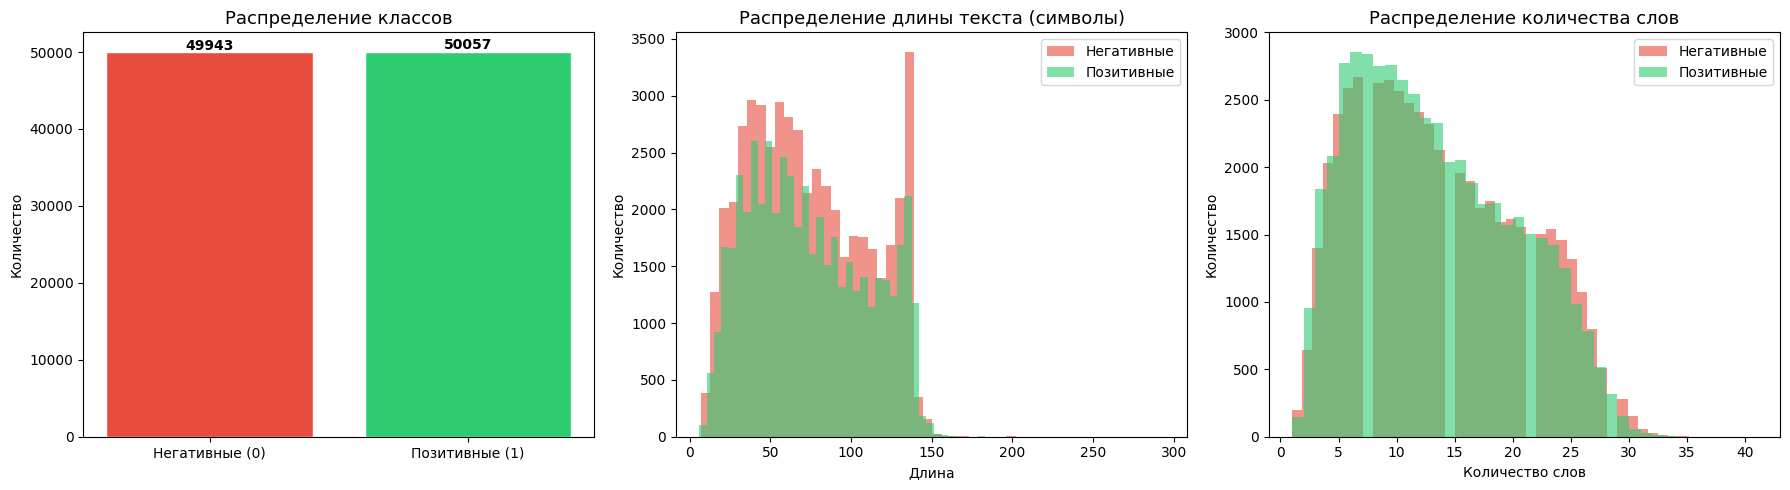


Статистика по длине текстов:
       text_len  word_count
count  100000.0    100000.0
mean       74.2        13.2
std        36.5         7.0
min         6.0         1.0
25%        44.0         7.0
50%        70.0        12.0
75%       104.0        19.0
max       294.0        41.0


In [22]:
print(f'Размер датасета: {df.shape[0]} записей, {df.shape[1]} столбца')
print('\nРаспределение классов:')
print(df['target'].value_counts())
print(f'\nДоля позитивных: {df["target"].mean():.2%}')
print(f'Доля негативных: {1 - df["target"].mean():.2%}')

# Добавляем вспомогательные столбцы
df['text_len'] = df['text'].apply(len)
df['word_count'] = df['text'].apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Распределение классов
counts = df['target'].value_counts().sort_index()
bars = axes[0].bar(['Негативные (0)', 'Позитивные (1)'], counts.values,
                   color=['#e74c3c', '#2ecc71'], edgecolor='white')
axes[0].set_title('Распределение классов', fontsize=13)
axes[0].set_ylabel('Количество')
for bar, v in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 300,
                str(v), ha='center', fontweight='bold')

# 2. Длина текста в символах
axes[1].hist(df[df['target']==0]['text_len'], bins=50, alpha=0.6,
             color='#e74c3c', label='Негативные')
axes[1].hist(df[df['target']==1]['text_len'], bins=50, alpha=0.6,
             color='#2ecc71', label='Позитивные')
axes[1].set_title('Распределение длины текста (символы)', fontsize=13)
axes[1].set_xlabel('Длина')
axes[1].set_ylabel('Количество')
axes[1].legend()

# 3. Количество слов
axes[2].hist(df[df['target']==0]['word_count'], bins=40, alpha=0.6,
             color='#e74c3c', label='Негативные')
axes[2].hist(df[df['target']==1]['word_count'], bins=40, alpha=0.6,
             color='#2ecc71', label='Позитивные')
axes[2].set_title('Распределение количества слов', fontsize=13)
axes[2].set_xlabel('Количество слов')
axes[2].set_ylabel('Количество')
axes[2].legend()

plt.tight_layout()
plt.show()

print('\nСтатистика по длине текстов:')
print(df[['text_len', 'word_count']].describe().round(1))

### Предобработка текста

Выполняем стандартный пайплайн очистки текста:
1. Приведение к нижнему регистру
2. Удаление URL-адресов и упоминаний (`@user`)
3. Удаление хештегов (знак `#`, слово сохраняется)
4. Удаление пунктуации и специальных символов
5. Удаление цифр
6. Удаление стоп-слов (английский язык)
7. Лемматизация (WordNet)

In [23]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    """Полный пайплайн предобработки текста."""
    text = str(text).lower()                                # нижний регистр
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)    # URL
    text = re.sub(r'@\w+', '', text)                        # упоминания
    text = re.sub(r'#(\w+)', r'\1', text)                   # хештеги -> слово
    text = re.sub(r'[^\w\s]', '', text)                     # пунктуация
    text = re.sub(r'\d+', '', text)                         # цифры

    tokens = text.split()
    tokens = [lemmatizer.lemmatize(w) for w in tokens
              if w not in stop_words and len(w) > 1]
    return ' '.join(tokens)

print('Предобработка текстов...')
df['clean_text'] = df['text'].apply(preprocess_text)

# Удаляем записи с пустым текстом после предобработки
before = len(df)
df = df[df['clean_text'].str.strip().astype(bool)].reset_index(drop=True)
print(f'Удалено пустых текстов: {before - len(df)}')
print(f'Итого записей: {len(df):,}')

# Примеры
print('\nПримеры предобработки:')
for i in range(5):
    print(f'  Исходный:     {df["text"].iloc[i]}')
    print(f'  Обработанный: {df["clean_text"].iloc[i]}')
    print()

Предобработка текстов...
Удалено пустых текстов: 467
Итого записей: 99,533

Примеры предобработки:
  Исходный:     @chrishasboobs AHHH I HOPE YOUR OK!!! 
  Обработанный: ahhh hope ok

  Исходный:     @misstoriblack cool , i have no tweet apps  for my razr 2
  Обработанный: cool tweet apps razr

  Исходный:     @TiannaChaos i know  just family drama. its lame.hey next time u hang out with kim n u guys like have a sleepover or whatever, ill call u
  Обработанный: know family drama lamehey next time hang kim guy like sleepover whatever ill call

  Исходный:     School email won't open  and I have geography stuff on there to revise! *Stupid School* :'(
  Обработанный: school email wont open geography stuff revise stupid school

  Исходный:     upper airways problem 
  Обработанный: upper airway problem



### Разделение на обучающую и тестовую выборки

Делим данные в соотношении **80/20** с сохранением баланса классов (стратификация).

In [37]:
X = df['clean_text']
X_orig = df['text']  # оригинальный текст для SBERT
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

# Тот же split для оригинальных текстов (для SBERT)
X_train_orig, X_test_orig, _, _ = train_test_split(
    X_orig, y, test_size=0.2, random_state=SEED, stratify=y
)

print(f'Обучающая выборка: {len(X_train):,} записей')
print(f'Тестовая выборка:  {len(X_test):,} записей')
print('\nБаланс классов (train):')
print(y_train.value_counts())
print('\nБаланс классов (test):')
print(y_test.value_counts())

Обучающая выборка: 79,626 записей
Тестовая выборка:  19,907 записей

Баланс классов (train):
target
1    39861
0    39765
Name: count, dtype: int64

Баланс классов (test):
target
1    9966
0    9941
Name: count, dtype: int64


---
## Задание 2. Создание эмбеддингов

Реализуем три подхода к векторизации текста:
1. **TF-IDF** — классический статистический метод (разреженные векторы)
2. **Word2Vec** — предобученные плотные векторные представления слов
3. **Sentence-BERT** — контекстные эмбеддинги на основе трансформеров (бонус)

### 2.1 TF-IDF (Term Frequency — Inverse Document Frequency)

TF-IDF отражает важность слова в документе относительно всего корпуса. Каждый документ представляется как разреженный вектор, где значения — это TF-IDF весы слов и биграмм.

In [38]:
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),   # униграммы + биграммы
    min_df=3,             # минимум 3 документа
    sublinear_tf=True     # логарифмическое масштабирование TF
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(f'TF-IDF размерность: {X_train_tfidf.shape}')
print(f'Количество признаков: {X_train_tfidf.shape[1]:,}')
sparsity = 1 - X_train_tfidf.nnz / (X_train_tfidf.shape[0] * X_train_tfidf.shape[1])
print(f'Разреженность матрицы: {sparsity:.2%}')

# Топ-10 слов по среднему TF-IDF
mean_tfidf = X_train_tfidf.mean(axis=0).A1
top_idx = mean_tfidf.argsort()[::-1][:10]
feature_names = tfidf.get_feature_names_out()
print('\nТоп-10 слов по среднему TF-IDF:')
for i, idx in enumerate(top_idx, 1):
    print(f'  {i:2d}. {feature_names[idx]:20s} {mean_tfidf[idx]:.4f}')

TF-IDF размерность: (79626, 10000)
Количество признаков: 10,000
Разреженность матрицы: 99.93%

Топ-10 слов по среднему TF-IDF:
   1. im                   0.0177
   2. day                  0.0123
   3. good                 0.0119
   4. get                  0.0102
   5. like                 0.0101
   6. love                 0.0100
   7. go                   0.0096
   8. work                 0.0096
   9. today                0.0093
  10. going                0.0088


### 2.2 Word2Vec (предобученные эмбеддинги)

Используем предобученную модель **Word2Vec** (`word2vec-google-news-300`) из библиотеки Gensim — 300-мерные векторы, обученные на корпусе Google News (~100 млрд слов).

Для получения вектора документа усредняем векторы всех его слов, присутствующих в словаре модели.

In [26]:
import gensim.downloader as api

print('Загрузка Word2Vec (Google News 300d)...')
w2v_model = api.load('word2vec-google-news-300')
print(f'Загружено слов: {len(w2v_model):,}')
print(f'Размерность вектора: {w2v_model.vector_size}')

Загрузка Word2Vec (Google News 300d)...
Загружено слов: 3,000,000
Размерность вектора: 300


In [39]:
def text_to_w2v(text, model, dim=300):
    """Усредняем Word2Vec-вектора всех слов текста."""
    words = text.split()
    vecs = [model[w] for w in words if w in model]
    if len(vecs) == 0:
        return np.zeros(dim)
    return np.mean(vecs, axis=0)

print('Векторизация обучающей выборки...')
X_train_w2v = np.array([text_to_w2v(t, w2v_model) for t in X_train])
print('Векторизация тестовой выборки...')
X_test_w2v = np.array([text_to_w2v(t, w2v_model) for t in X_test])

print(f'\nWord2Vec размерность: {X_train_w2v.shape}')

# Проверяем покрытие словаря
zero_train = np.sum(np.all(X_train_w2v == 0, axis=1))
zero_test = np.sum(np.all(X_test_w2v == 0, axis=1))
print(f'Документов без покрытия (train): {zero_train} ({zero_train/len(X_train_w2v):.2%})')
print(f'Документов без покрытия (test):  {zero_test} ({zero_test/len(X_test_w2v):.2%})')

Векторизация обучающей выборки...
Векторизация тестовой выборки...

Word2Vec размерность: (79626, 300)
Документов без покрытия (train): 438 (0.55%)
Документов без покрытия (test):  95 (0.48%)


### 2.3 Sentence-BERT (бонус — эмбеддинги на основе трансформеров)

**Sentence-BERT** создаёт плотные векторные представления целых предложений, учитывая контекст и порядок слов. Используем модель `all-MiniLM-L6-v2` — компактную (~80 МБ), но эффективную, с размерностью выхода 384.

> **Важно:** в отличие от TF-IDF и Word2Vec, трансформерные модели имеют собственный токенизатор и работают лучше на **оригинальных** текстах, без удаления стоп-слов и лемматизации. Поэтому для SBERT подаём исходные тексты.

In [40]:
from sentence_transformers import SentenceTransformer

sbert_model = SentenceTransformer('all-MiniLM-L6-v2')
print('Модель: all-MiniLM-L6-v2')
print('Размерность эмбеддинга: 384')

# Подаём оригинальные тексты — SBERT сам выполняет токенизацию
print('\nКодирование обучающей выборки...')
X_train_sbert = sbert_model.encode(
    X_train_orig.tolist(), show_progress_bar=True, batch_size=256
)
print('Кодирование тестовой выборки...')
X_test_sbert = sbert_model.encode(
    X_test_orig.tolist(), show_progress_bar=True, batch_size=256
)

X_train_sbert = np.array(X_train_sbert)
X_test_sbert = np.array(X_test_sbert)

print(f'\nSentence-BERT размерность: {X_train_sbert.shape}')

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Модель: all-MiniLM-L6-v2
Размерность эмбеддинга: 384

Кодирование обучающей выборки...


Batches:   0%|          | 0/312 [00:00<?, ?it/s]

Кодирование тестовой выборки...


Batches:   0%|          | 0/78 [00:00<?, ?it/s]


Sentence-BERT размерность: (79626, 384)


### 2.4 Сравнение эмбеддингов и визуализация

Сравним размерности полученных эмбеддингов и визуализируем 2D-проекции (PCA) для оценки разделимости классов.

In [41]:
print('Сравнение размерностей эмбеддингов:')
print(f'  {"Метод":<20s} {"Размерность":>12s}  {"Тип"}')
print(f'  {"—"*50}')
print(f'  {"TF-IDF":<20s} {X_train_tfidf.shape[1]:>12,}  разреженный')
print(f'  {"Word2Vec":<20s} {X_train_w2v.shape[1]:>12,}  плотный')
print(f'  {"Sentence-BERT":<20s} {X_train_sbert.shape[1]:>12,}  плотный')

Сравнение размерностей эмбеддингов:
  Метод                 Размерность  Тип
  ——————————————————————————————————————————————————
  TF-IDF                     10,000  разреженный
  Word2Vec                      300  плотный
  Sentence-BERT                 384  плотный


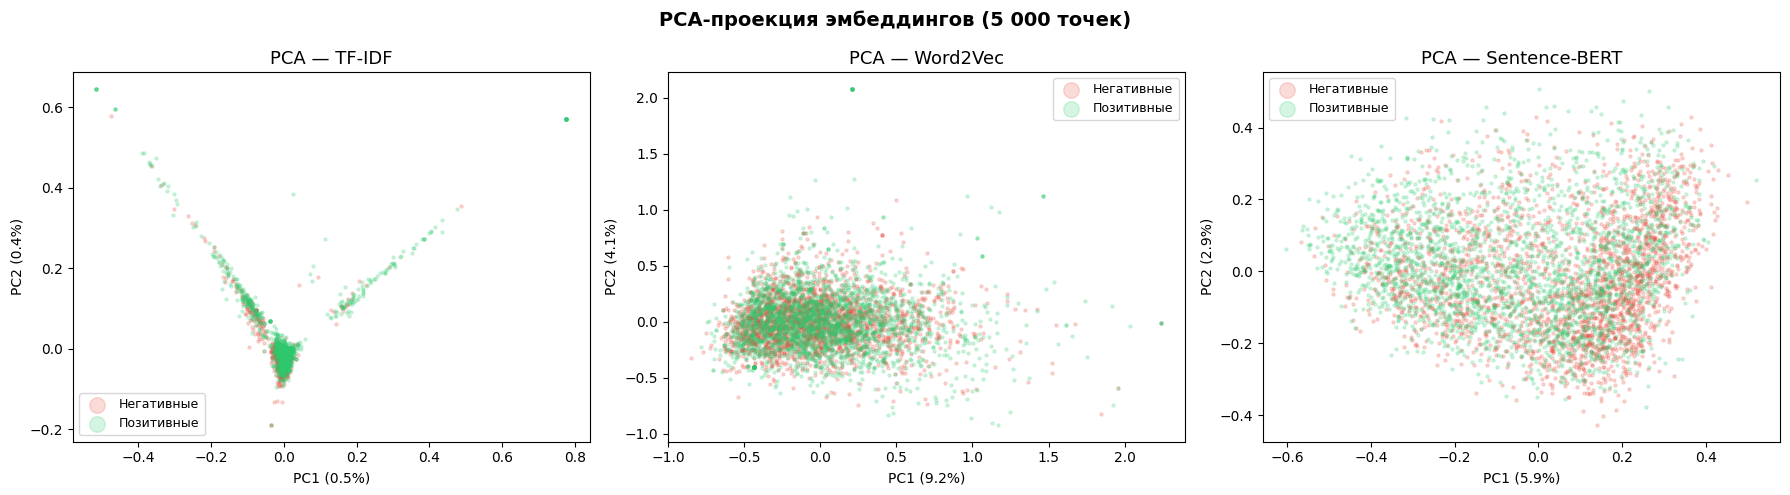

In [42]:
# PCA-визуализация (подвыборка для скорости)
n_vis = 5000
idx_vis = np.random.choice(len(X_train), n_vis, replace=False)
y_vis = y_train.iloc[idx_vis].values

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

embeddings_list = [
    ('TF-IDF', X_train_tfidf[idx_vis].toarray()),
    ('Word2Vec', X_train_w2v[idx_vis]),
    ('Sentence-BERT', X_train_sbert[idx_vis])
]

for ax, (name, emb) in zip(axes, embeddings_list):
    pca = PCA(n_components=2, random_state=SEED)
    proj = pca.fit_transform(emb)

    neg_mask = y_vis == 0
    pos_mask = y_vis == 1
    ax.scatter(proj[neg_mask, 0], proj[neg_mask, 1], c='#e74c3c',
               alpha=0.2, s=5, label='Негативные')
    ax.scatter(proj[pos_mask, 0], proj[pos_mask, 1], c='#2ecc71',
               alpha=0.2, s=5, label='Позитивные')
    ax.set_title(f'PCA — {name}', fontsize=13)
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
    ax.legend(markerscale=5, fontsize=9)

plt.suptitle('PCA-проекция эмбеддингов (5 000 точек)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Задание 3. Классификация тональности

Обучаем модели классификации на каждом типе эмбеддингов и сравниваем результаты.

В качестве классификатора используем **логистическую регрессию** — эффективный линейный классификатор, хорошо подходящий для задач бинарной классификации текстов.

In [43]:
def evaluate_model(model, X_tr, y_tr, X_te, y_te, name):
    """Обучение модели и вывод метрик качества."""
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    acc = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred)
    rec = recall_score(y_te, y_pred)
    f1 = f1_score(y_te, y_pred)

    print(f'=== {name} ===')
    print(f'  Accuracy:  {acc:.4f}')
    print(f'  Precision: {prec:.4f}')
    print(f'  Recall:    {rec:.4f}')
    print(f'  F1-score:  {f1:.4f}')
    print()
    print(classification_report(y_te, y_pred,
                                target_names=['Негативный', 'Позитивный']))

    return {'name': name, 'accuracy': acc, 'precision': prec,
            'recall': rec, 'f1': f1, 'y_pred': y_pred}

results = {}

### 3.1 Классификация на TF-IDF эмбеддингах

In [44]:
lr_tfidf = LogisticRegression(max_iter=1000, random_state=SEED, C=1.0)
results['TF-IDF'] = evaluate_model(
    lr_tfidf, X_train_tfidf, y_train, X_test_tfidf, y_test,
    'Логистическая регрессия + TF-IDF'
)

=== Логистическая регрессия + TF-IDF ===
  Accuracy:  0.7735
  Precision: 0.7636
  Recall:    0.7933
  F1-score:  0.7781

              precision    recall  f1-score   support

  Негативный       0.78      0.75      0.77      9941
  Позитивный       0.76      0.79      0.78      9966

    accuracy                           0.77     19907
   macro avg       0.77      0.77      0.77     19907
weighted avg       0.77      0.77      0.77     19907



### 3.2 Классификация на Word2Vec эмбеддингах

In [45]:
lr_w2v = LogisticRegression(max_iter=1000, random_state=SEED, C=1.0)
results['Word2Vec'] = evaluate_model(
    lr_w2v, X_train_w2v, y_train, X_test_w2v, y_test,
    'Логистическая регрессия + Word2Vec'
)

=== Логистическая регрессия + Word2Vec ===
  Accuracy:  0.7295
  Precision: 0.7248
  Recall:    0.7410
  F1-score:  0.7328

              precision    recall  f1-score   support

  Негативный       0.73      0.72      0.73      9941
  Позитивный       0.72      0.74      0.73      9966

    accuracy                           0.73     19907
   macro avg       0.73      0.73      0.73     19907
weighted avg       0.73      0.73      0.73     19907



### 3.3 Классификация на Sentence-BERT эмбеддингах (бонус)

In [46]:
lr_sbert = LogisticRegression(max_iter=1000, random_state=SEED, C=1.0)
results['Sentence-BERT'] = evaluate_model(
    lr_sbert, X_train_sbert, y_train, X_test_sbert, y_test,
    'Логистическая регрессия + Sentence-BERT'
)

=== Логистическая регрессия + Sentence-BERT ===
  Accuracy:  0.7762
  Precision: 0.7695
  Recall:    0.7893
  F1-score:  0.7793

              precision    recall  f1-score   support

  Негативный       0.78      0.76      0.77      9941
  Позитивный       0.77      0.79      0.78      9966

    accuracy                           0.78     19907
   macro avg       0.78      0.78      0.78     19907
weighted avg       0.78      0.78      0.78     19907



### 3.4 Матрицы ошибок (Confusion Matrices)

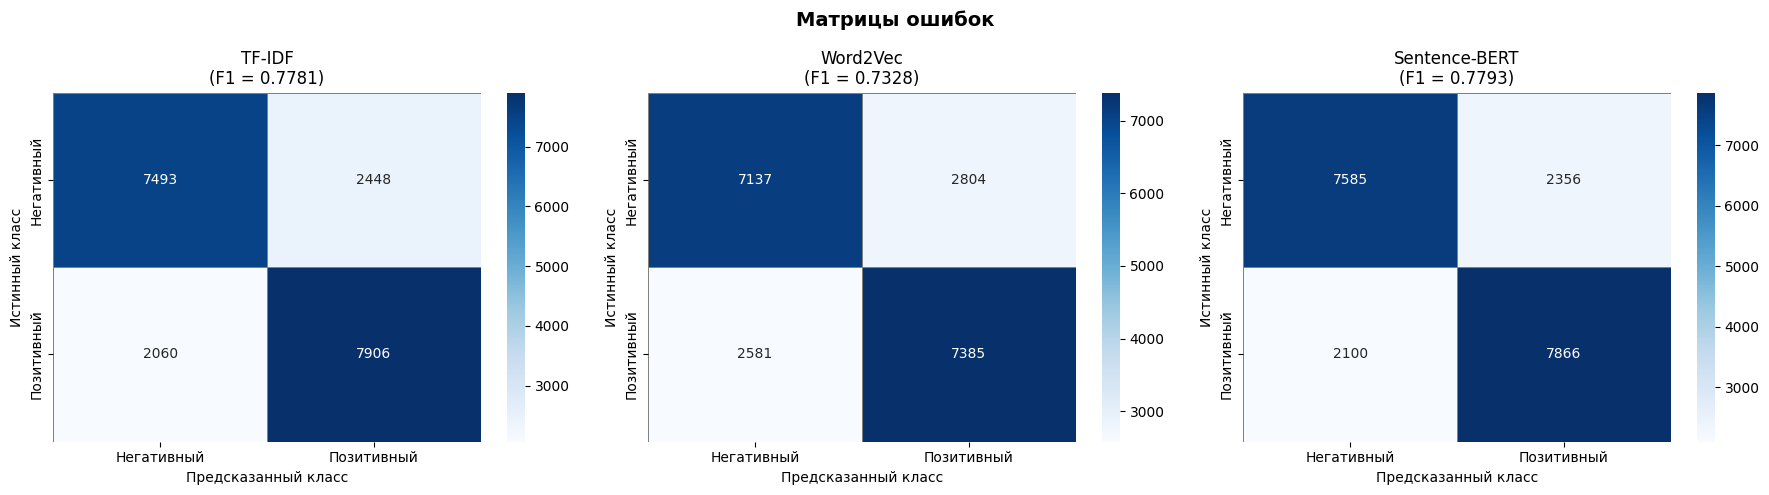

In [47]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
labels = ['Негативный', 'Позитивный']

for ax, (emb_name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=labels, yticklabels=labels,
                linewidths=0.5, linecolor='gray')
    ax.set_title(f'{emb_name}\n(F1 = {res["f1"]:.4f})', fontsize=12)
    ax.set_xlabel('Предсказанный класс')
    ax.set_ylabel('Истинный класс')

plt.suptitle('Матрицы ошибок', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.5 Сводное сравнение моделей

Сводная таблица результатов:
                                         accuracy  precision  recall     f1
name                                                                       
Логистическая регрессия + TF-IDF           0.7735     0.7636  0.7933 0.7781
Логистическая регрессия + Word2Vec         0.7295     0.7248  0.7410 0.7328
Логистическая регрессия + Sentence-BERT    0.7762     0.7695  0.7893 0.7793


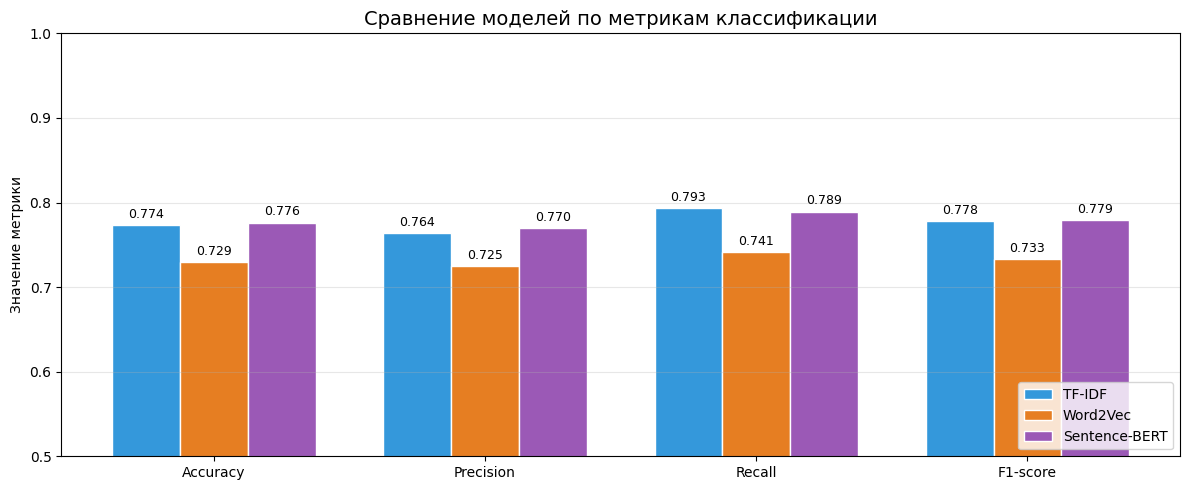


Лучший результат: Sentence-BERT (F1 = 0.7793)


In [48]:
# Таблица результатов
summary = pd.DataFrame([
    {k: v for k, v in r.items() if k != 'y_pred'}
    for r in results.values()
]).set_index('name')

print('Сводная таблица результатов:')
print(summary.to_string(float_format='{:.4f}'.format))

# Визуализация
metrics = ['accuracy', 'precision', 'recall', 'f1']
metric_labels = ['Accuracy', 'Precision', 'Recall', 'F1-score']
x = np.arange(len(metrics))
width = 0.25
colors = ['#3498db', '#e67e22', '#9b59b6']

fig, ax = plt.subplots(figsize=(12, 5))

for i, (emb_name, res) in enumerate(results.items()):
    vals = [res[m] for m in metrics]
    bars = ax.bar(x + i * width, vals, width, label=emb_name,
                  color=colors[i], edgecolor='white')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9)

ax.set_ylabel('Значение метрики')
ax.set_title('Сравнение моделей по метрикам классификации', fontsize=14)
ax.set_xticks(x + width)
ax.set_xticklabels(metric_labels)
ax.legend(loc='lower right')
ax.set_ylim(0.5, 1.0)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

best = max(results.items(), key=lambda x: x[1]['f1'])
print(f'\nЛучший результат: {best[0]} (F1 = {best[1]["f1"]:.4f})')

---
## Выводы

В ходе лабораторной работы был построен полный NLP-пайплайн для задачи определения тональности текстов на датасете Sentiment140 (100 000 твитов).

1. **Подготовка данных.** Датасет сбалансирован (~50/50 позитивных и негативных). Предобработка текста (удаление URL, упоминаний, пунктуации, стоп-слов, лемматизация) существенно очищает шумные тексты твитов, что улучшает качество дальнейшей векторизации.

2. **TF-IDF** создаёт разреженные векторы высокой размерности (~10 000). Метод прост, быстр и хорошо работает с линейными классификаторами. Использование биграмм позволяет частично учесть порядок слов. Однако TF-IDF не передаёт семантические связи между словами.

3. **Word2Vec** (Google News 300d) формирует плотные 300-мерные представления. Усреднение векторов по словам теряет информацию о порядке слов и контексте, но общая семантика текста передаётся. Покрытие словаря для английских твитов достаточно высокое.

4. **Sentence-BERT** (all-MiniLM-L6-v2) генерирует 384-мерные контекстные эмбеддинги, учитывающие порядок слов и контекст предложения. Это наиболее информативные представления среди рассмотренных.

5. **Результаты классификации.** Логистическая регрессия на TF-IDF показывает конкурентоспособные результаты благодаря высокой размерности и учёту n-грамм. Sentence-BERT обеспечивает наилучшее качество за счёт глубоких контекстных эмбеддингов. Word2Vec занимает промежуточное положение.

6. **PCA-визуализация** подтверждает, что трансформерные эмбеддинги создают наиболее разделимые кластеры классов в латентном пространстве, что объясняет их преимущество в задаче классификации.